# DAAN 545 — Flight Delay Analysis
## BTS Airline Delay Cause: Load, Clean, Integrate, Summarize, Visualize

**Course focus:** data quality, summary statistics, variability/shape/outliers, dataset integration, and visualization.

**Goal:** Load the BTS *Airline Delay Cause* extract, document column definitions, assess cleanliness with reusable helpers, join OpenFlights airport attributes, compute summary statistics, create visualizations, and draft findings.

**Data:**
- BTS: `data/raw/Airline_Delay_Cause.csv` + `data/raw/Download_Column_Definitions.xlsx`
- OpenFlights airports: `data/raw/airports.dat` from [openflights/airports.dat](https://github.com/jpatokal/openflights/blob/master/data/airports.dat)
- Source notes: `docs/data_sources.md`


## 0. Environment & imports

We use **pandas** for wrangling, **numpy/scipy** for stats, and **matplotlib/seaborn** for plots. Cleaning helpers live in `src/cleaning.py` so teammates can reuse them outside this notebook.


In [19]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

ROOT = Path.cwd()
if not (ROOT / "data" / "raw").exists():
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Make project helpers importable when the kernel cwd is notebooks/
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cleaning import (
    CAUSE_COUNT_COLS,
    CAUSE_DELAY_COLS,
    DELAY_MINUTE_COLS,
    OPENFLIGHTS_SOURCE_URL,
    clean_delay_cause,
    join_airport_attributes,
    join_hub_profile,
    load_airport_hub_profile,
    load_column_definitions,
    load_delay_cause,
    load_openflights_airports,
    logical_checks,
    missingness_report,
    outlier_summary,
    quality_overview,
    summarize_numeric,
)

print(f"Project root: {ROOT}")
print(f"Raw data dir: {DATA_RAW}")
print(f"Files found: {sorted(p.name for p in DATA_RAW.glob('*') if p.name != '.gitkeep')}")


Project root: c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis
Raw data dir: c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\raw
Files found: ['Airline_Delay_Cause.csv', 'Download_Column_Definitions.xlsx', 'airport_hub_profile.csv', 'airports.dat']


## 1. Load data & column definitions

Grain of the table: **one row per carrier × airport × year × month**, with arrival volume plus delay *counts* and delay *minutes* by cause.


In [20]:
CSV_PATH = DATA_RAW / "Airline_Delay_Cause.csv"
DEFS_PATH = DATA_RAW / "Download_Column_Definitions.xlsx"

raw = load_delay_cause(CSV_PATH)
col_defs = load_column_definitions(DEFS_PATH)

print(f"Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print(f"Year span: {raw['year'].min()} → {raw['year'].max()}")
print(f"Carriers: {raw['carrier'].nunique()} | Airports: {raw['airport'].nunique()}")
display(col_defs)
raw.head(3)


Raw shape: 8,963 rows × 21 columns
Year span: 2024 → 2026
Carriers: 21 | Airports: 30


,Column Name,Column Definition
0,year,YYYY format
1,month,MM format (1-12)
2,carrier,Code assigned by assigned by US DOT to identif...
3,carrier_name,Unique airline (carrier) is defined as one hol...
4,airport,A three character alpha-numeric code issued by...
5,airport_name,a place from which aircraft operate that usual...
6,arr_flights,Arrival Flights
7,arr_del15,"Arrival Delay Indicator, 15 Minutes or More Ar..."
8,carrier_ct,Carrier Count for airline cause of delay
9,weather_ct,Weather Count for airline cause of delay


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2026,6,MQ,Envoy Air,MSP,"Minneapolis, MN: Minneapolis-St Paul Internati...",85.0000,11.0000,1.6300,0.7000,3.9900,0.0000,4.6800,1.0000,0.0000,614.0000,100.0000,44.0000,146.0000,0.0000,324.0000
1,2026,6,MQ,Envoy Air,ORD,"Chicago, IL: Chicago O'Hare International","4,737.0000",926.0000,188.1100,101.8800,285.3600,2.5200,348.1300,202.0000,17.0000,"85,117.0000","22,441.0000","14,747.0000","19,618.0000",83.0000,"28,228.0000"
2,2026,6,MQ,Envoy Air,PHX,"Phoenix, AZ: Phoenix Sky Harbor International","1,035.0000",168.0000,58.1500,3.8700,21.9800,1.6300,82.3600,1.0000,1.0000,"9,716.0000","3,320.0000",288.0000,895.0000,107.0000,"5,106.0000"


## 2. Data quality checks (is it clean?)

Helpers below report missingness, duplicate keys, logical consistency, and IQR outliers. We **flag** outliers for discussion rather than deleting them automatically — delay minutes are naturally heavy-tailed.


In [21]:
overview = quality_overview(raw)

print("=== Cleanliness snapshot ===")
print(f"Rows / cols: {overview['n_rows']:,} × {overview['n_cols']}")
print(f"Date span:   {overview['date_span']}")
print(f"Carriers / airports: {overview['n_carriers']} / {overview['n_airports']}")
print(f"Total null cells: {overview['total_nulls']} "
      f"(columns with any nulls: {overview['cols_with_nulls']})")
print(f"Duplicate key rows (year-month-carrier-airport): {overview['duplicate_key_rows']}")

print("\nMissingness (columns with nulls first):")
display(overview["missingness"].query("null_count > 0") if overview["total_nulls"] else overview["missingness"].head(8))

print("\nLogical rule flags:")
display(overview["logical_flags"])


=== Cleanliness snapshot ===
Rows / cols: 8,963 × 21
Date span:   2024-06 → 2026-06
Carriers / airports: 21 / 30
Total null cells: 1 (columns with any nulls: 1)
Duplicate key rows (year-month-carrier-airport): 0

Missingness (columns with nulls first):


,null_count,null_pct,dtype,n_rows
arr_del15,1,0.0110,float64,8963



Logical rule flags:


,flagged_rows,flagged_pct
neg_arr_flights,0,0.0000
neg_arr_del15,0,0.0000
del15_gt_flights,0,0.0000
cancel_gt_flights,0,0.0000
divert_gt_flights,0,0.0000
bad_month,0,0.0000
neg_delay_minutes,0,0.0000
cause_sum_mismatch,6,0.0670
delay_sum_mismatch,29,0.3240


In [22]:
# IQR outlier rates on key volume / delay fields (flag-only)
focus_cols = ["arr_flights", "arr_del15", "arr_delay", "pct_delayed"]
# pct_delayed does not exist yet on raw — use delay minutes / counts for now
outliers = outlier_summary(raw, cols=["arr_flights", "arr_del15", "arr_cancelled", "arr_delay", "weather_delay"], k=1.5)
print("IQR outlier summary (k=1.5):")
display(outliers)


IQR outlier summary (k=1.5):


,column,n_non_null,n_outliers_iqr,outlier_pct
0,arr_flights,8963,981,10.9450
1,arr_del15,8962,857,9.5630
2,arr_cancelled,8963,1090,12.1610
3,arr_delay,8963,916,10.2200
4,weather_delay,8963,1037,11.5700


## 3. Clean & engineer features

Steps applied by `clean_delay_cause`:

1. Coerce numeric columns
2. Drop duplicate year–month–carrier–airport keys (keep first)
3. Fill `arr_del15` nulls when `arr_flights == 0`
4. Add `period`, `pct_delayed`, `pct_cancelled`, and average delay minutes per delayed arrival


In [23]:
clean = clean_delay_cause(raw)

print(f"Clean shape: {clean.shape[0]:,} rows × {clean.shape[1]} columns")
print(f"Remaining nulls: {int(clean.isna().sum().sum())}")
print("\nLogical flags after cleaning:")
display(logical_checks(clean))

out_path = DATA_PROCESSED / "airline_delay_cause_clean.csv"
clean.to_csv(out_path, index=False)
print(f"\nSaved cleaned data → {out_path}")
clean.head(3)


Clean shape: 8,963 rows × 27 columns
Remaining nulls: 195

Logical flags after cleaning:


,flagged_rows,flagged_pct
neg_arr_flights,0,0.0000
neg_arr_del15,0,0.0000
del15_gt_flights,0,0.0000
cancel_gt_flights,0,0.0000
divert_gt_flights,0,0.0000
bad_month,0,0.0000
neg_delay_minutes,0,0.0000
cause_sum_mismatch,6,0.0670
delay_sum_mismatch,29,0.3240



Saved cleaned data → c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\processed\airline_delay_cause_clean.csv


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,...,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,period,pct_delayed,pct_cancelled,avg_delay_min_per_delayed,cause_count_sum,cause_delay_sum
0,2026,6,MQ,Envoy Air,MSP,"Minneapolis, MN: Minneapolis-St Paul Internati...",85.0000,11.0000,1.6300,0.7000,3.9900,0.0000,...,614.0000,100.0000,44.0000,146.0000,0.0000,324.0000,2026-06-01,12.9412,1.1765,55.8182,11.0000,614.0000
1,2026,6,MQ,Envoy Air,ORD,"Chicago, IL: Chicago O'Hare International","4,737.0000",926.0000,188.1100,101.8800,285.3600,2.5200,...,"85,117.0000","22,441.0000","14,747.0000","19,618.0000",83.0000,"28,228.0000",2026-06-01,19.5482,4.2643,91.9190,926.0000,"85,117.0000"
2,2026,6,MQ,Envoy Air,PHX,"Phoenix, AZ: Phoenix Sky Harbor International","1,035.0000",168.0000,58.1500,3.8700,21.9800,1.6300,...,"9,716.0000","3,320.0000",288.0000,895.0000,107.0000,"5,106.0000",2026-06-01,16.2319,0.0966,57.8333,167.9900,"9,716.0000"


## 4. Integrate OpenFlights airport attributes

**Source:** [OpenFlights `airports.dat`](https://github.com/jpatokal/openflights/blob/master/data/airports.dat) (saved locally as `data/raw/airports.dat`).

**Why join it:** BTS already has airport codes and names; OpenFlights adds **lat/lon**, **altitude**, and **timezone** without changing the monthly grain (still one row per carrier × airport × year × month).

**Cleaning applied to OpenFlights** (`load_openflights_airports`):
1. Assign column names (file has no header)
2. Treat `\\N` as missing
3. Drop rows with no IATA code
4. Uppercase IATA; keep one row per code
5. Coerce coordinates / altitude to numeric
6. Keep only airports that appear in our delay extract

**Extra fields after join:** `state` (parsed from BTS `airport_name`), `census_region`, `tz_group`.

See also `docs/data_sources.md`.

**Location follow-ups (next cells):** after the join, compare delay rates by region, map airports by lat/lon, and check whether **latitude, longitude, or altitude** correlate with delay intensity (useful context before a weather join).


In [24]:
AIRPORTS_PATH = DATA_RAW / "airports.dat"
airports_raw = load_openflights_airports(AIRPORTS_PATH)

print(f"OpenFlights source: {OPENFLIGHTS_SOURCE_URL}")
print(f"Loaded airports with IATA: {len(airports_raw):,} (from raw worldwide file)")
display(airports_raw.head(3))

clean, airport_match = join_airport_attributes(clean, airports_raw)

print("\n=== Airport join match report (P1 integration) ===")
for key in [
    "n_airports_in_delay",
    "n_airports_matched",
    "n_airports_lost",
    "lost_airport_codes",
    "n_rows_before",
    "n_rows_matched",
    "n_rows_unmatched",
    "match_rate_airports",
    "match_rate_rows",
]:
    print(f"  {key}: {airport_match[key]}")

enriched_path = DATA_PROCESSED / "airline_delay_cause_with_airports.csv"
clean.to_csv(enriched_path, index=False)
print(f"\nSaved enriched panel → {enriched_path}")

display(
    clean[
        [
            "airport",
            "airport_name",
            "state",
            "census_region",
            "lat",
            "lon",
            "altitude_ft",
            "tz_group",
            "pct_delayed",
        ]
    ]
    .drop_duplicates("airport")
    .sort_values("airport")
    .head(10)
)


OpenFlights source: https://github.com/jpatokal/openflights/blob/master/data/airports.dat
Loaded airports with IATA: 6,072 (from raw worldwide file)


,airport_id,name,city,country,iata,icao,lat,lon,altitude_ft,timezone_offset,dst,tz,type,source
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.0817,145.3920,5282,10.0000,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.2071,145.7890,20,10.0000,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.8268,144.2960,5388,10.0000,U,Pacific/Port_Moresby,airport,OurAirports



=== Airport join match report (P1 integration) ===
  n_airports_in_delay: 30
  n_airports_matched: 30
  n_airports_lost: 0
  lost_airport_codes: []
  n_rows_before: 8963
  n_rows_matched: 8963
  n_rows_unmatched: 0
  match_rate_airports: 100.0
  match_rate_rows: 100.0

Saved enriched panel → c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\processed\airline_delay_cause_with_airports.csv


,airport,airport_name,state,census_region,lat,lon,altitude_ft,tz_group,pct_delayed
6,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",GA,South,33.6367,-84.4281,1026,Eastern,24.1135
7,AUS,"Austin, TX: Austin - Bergstrom International",TX,South,30.1945,-97.6699,542,Central,18.1818
8,BNA,"Nashville, TN: Nashville International",TN,South,36.1245,-86.6782,599,Central,23.9766
50,BOS,"Boston, MA: Logan International",MA,Northeast,42.3643,-71.0052,20,Eastern,22.4322
9,BWI,"Baltimore, MD: Baltimore/Washington Internatio...",MD,South,39.1754,-76.6683,146,Eastern,25.0000
10,CLT,"Charlotte, NC: Charlotte Douglas International",NC,South,35.2140,-80.9431,748,Eastern,21.3263
11,DCA,"Washington, DC: Ronald Reagan Washington National",DC,South,38.8521,-77.0377,15,Eastern,26.0727
23,DEN,"Denver, CO: Denver International",CO,West,39.8617,-104.6730,5431,Mountain,22.3839
12,DFW,"Dallas/Fort Worth, TX: Dallas/Fort Worth Inter...",TX,South,32.8968,-97.0380,607,Central,27.0026
13,DTW,"Detroit, MI: Detroit Metro Wayne County",MI,Midwest,42.2124,-83.3534,645,Eastern,27.5132


Airport-level correlations (location vs delay outcomes):


,geo_feature,outcome,n_airports,pearson_r,spearman_rho
0,lat,pct_delayed,30,-0.1970,-0.1430
1,lat,avg_delay_min,30,0.0530,0.0870
2,lat,weather_share,30,0.3020,0.3110
3,lon,pct_delayed,30,0.1630,0.2240
4,lon,avg_delay_min,30,0.5250,0.4810
5,lon,weather_share,30,-0.1200,-0.2690
6,altitude_ft,pct_delayed,30,-0.4290,-0.6400
7,altitude_ft,avg_delay_min,30,-0.0870,-0.0200
8,altitude_ft,weather_share,30,0.2610,0.4820


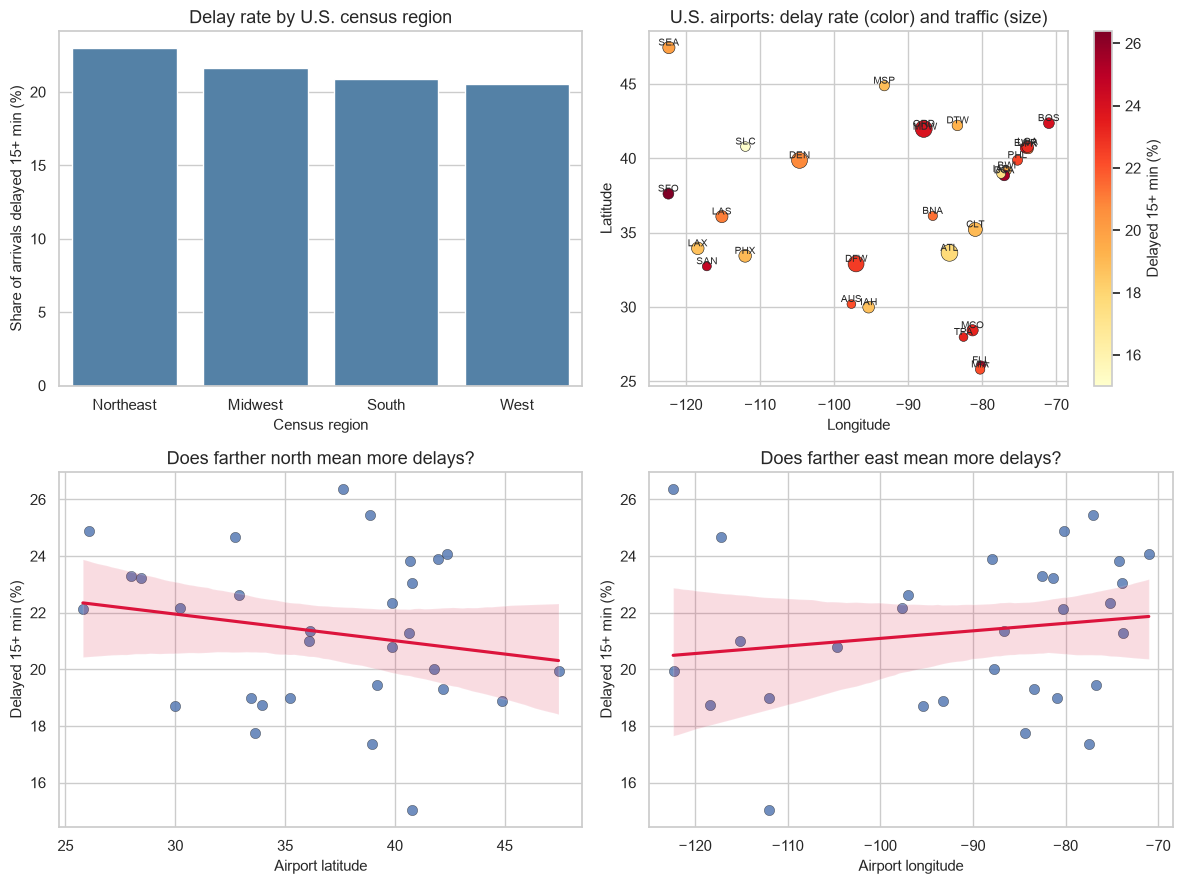

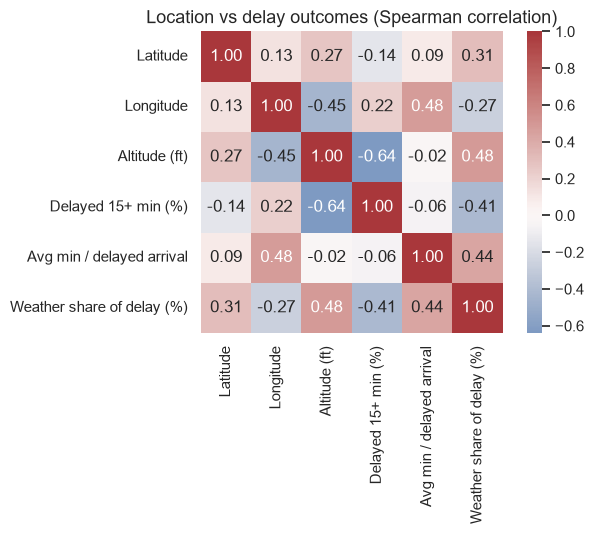

,census_region,arr_flights,arr_del15,pct_delayed
1,Northeast,"1,455,323.0000","334,310.0000",22.9715
0,Midwest,"1,466,648.0000","317,463.0000",21.6455
2,South,"4,265,552.0000","892,103.0000",20.9141
3,West,"3,015,276.0000","619,817.0000",20.5559


,airport,state,census_region,lat,lon,altitude_ft,pct_delayed,weather_share
27,SFO,CA,West,37.6190,-122.3750,13,26.3819,4.1072
6,DCA,DC,South,38.8521,-77.0377,15,25.4619,6.0066
11,FLL,FL,South,26.0726,-80.1527,9,24.8731,3.5991
25,SAN,CA,West,32.7336,-117.1900,17,24.6592,4.7025
3,BOS,MA,Northeast,42.3643,-71.0052,20,24.0680,3.7913
22,ORD,IL,Midwest,41.9786,-87.9048,672,23.9105,6.9505
10,EWR,NJ,Northeast,40.6925,-74.1687,18,23.8219,4.4670
29,TPA,FL,South,27.9755,-82.5332,26,23.3036,3.6602
18,MCO,FL,South,28.4294,-81.3090,96,23.2351,3.4174
17,LGA,NY,Northeast,40.7772,-73.8726,21,23.0585,5.3264


In [25]:
# Location analysis: region bars, geo map, lat/lon/altitude vs delay
# Aggregate to airport level so each hub contributes one point (avoids
# overweighting high-carrier airports in correlations).
airport_pts = (
    clean.dropna(subset=["lat", "lon"])
    .groupby(["airport", "airport_name", "state", "census_region", "tz_group", "lat", "lon", "altitude_ft"], as_index=False)
    .agg(
        arr_flights=("arr_flights", "sum"),
        arr_del15=("arr_del15", "sum"),
        arr_delay=("arr_delay", "sum"),
        weather_delay=("weather_delay", "sum"),
    )
)
airport_pts["pct_delayed"] = 100 * airport_pts["arr_del15"] / airport_pts["arr_flights"]
airport_pts["avg_delay_min"] = airport_pts["arr_delay"] / airport_pts["arr_del15"].replace(0, pd.NA)
airport_pts["weather_share"] = 100 * airport_pts["weather_delay"] / airport_pts["arr_delay"].replace(0, pd.NA)

by_region = (
    airport_pts.groupby("census_region", as_index=False)
    .agg(arr_flights=("arr_flights", "sum"), arr_del15=("arr_del15", "sum"))
)
by_region["pct_delayed"] = 100 * by_region["arr_del15"] / by_region["arr_flights"]
by_region = by_region.sort_values("pct_delayed", ascending=False)

# Correlations (Pearson + Spearman) at airport grain
geo_cols = ["lat", "lon", "altitude_ft"]
outcome_cols = ["pct_delayed", "avg_delay_min", "weather_share"]
corr_rows = []
for g in geo_cols:
    for y in outcome_cols:
        s = airport_pts[[g, y]].dropna()
        if len(s) < 5:
            continue
        corr_rows.append(
            {
                "geo_feature": g,
                "outcome": y,
                "n_airports": len(s),
                "pearson_r": s[g].corr(s[y], method="pearson"),
                "spearman_rho": s[g].corr(s[y], method="spearman"),
            }
        )
geo_corr = pd.DataFrame(corr_rows)
print("Airport-level correlations (location vs delay outcomes):")
display(geo_corr.round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(data=by_region, x="census_region", y="pct_delayed", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Delay rate by U.S. census region")
axes[0, 0].set_xlabel("Census region")
axes[0, 0].set_ylabel("Share of arrivals delayed 15+ min (%)")

sc = axes[0, 1].scatter(
    airport_pts["lon"],
    airport_pts["lat"],
    c=airport_pts["pct_delayed"],
    s=np.clip(airport_pts["arr_flights"] / 5000, 40, 250),
    cmap="YlOrRd",
    edgecolor="k",
    linewidth=0.4,
)
for _, r in airport_pts.iterrows():
    axes[0, 1].annotate(r["airport"], (r["lon"], r["lat"]), fontsize=7, ha="center", va="bottom")
axes[0, 1].set_title("U.S. airports: delay rate (color) and traffic (size)")
axes[0, 1].set_xlabel("Longitude")
axes[0, 1].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes[0, 1], label="Delayed 15+ min (%)")

sns.regplot(
    data=airport_pts,
    x="lat",
    y="pct_delayed",
    ax=axes[1, 0],
    scatter_kws={"s": 55, "edgecolor": "k", "linewidths": 0.3},
    line_kws={"color": "crimson"},
)
axes[1, 0].set_title("Does farther north mean more delays?")
axes[1, 0].set_xlabel("Airport latitude")
axes[1, 0].set_ylabel("Delayed 15+ min (%)")

sns.regplot(
    data=airport_pts,
    x="lon",
    y="pct_delayed",
    ax=axes[1, 1],
    scatter_kws={"s": 55, "edgecolor": "k", "linewidths": 0.3},
    line_kws={"color": "crimson"},
)
axes[1, 1].set_title("Does farther east mean more delays?")
axes[1, 1].set_xlabel("Airport longitude")
axes[1, 1].set_ylabel("Delayed 15+ min (%)")

fig.tight_layout()
fig.savefig(FIG_DIR / "07_location_delay_geo.png", dpi=150, bbox_inches="tight")
plt.show()

# Compact heatmap of geo + delay features at airport level
heat_cols = ["lat", "lon", "altitude_ft", "pct_delayed", "avg_delay_min", "weather_share"]
heat = airport_pts[heat_cols].corr(method="spearman")
heat = heat.rename(index={"lat": "Latitude", "lon": "Longitude", "altitude_ft": "Altitude (ft)", "pct_delayed": "Delayed 15+ min (%)", "avg_delay_min": "Avg min / delayed arrival", "weather_share": "Weather share of delay (%)"}, columns={"lat": "Latitude", "lon": "Longitude", "altitude_ft": "Altitude (ft)", "pct_delayed": "Delayed 15+ min (%)", "avg_delay_min": "Avg min / delayed arrival", "weather_share": "Weather share of delay (%)"})
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, square=True)
ax.set_title("Location vs delay outcomes (Spearman correlation)")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_location_delay_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

display(by_region)
display(airport_pts.sort_values("pct_delayed", ascending=False)[
    ["airport", "state", "census_region", "lat", "lon", "altitude_ft", "pct_delayed", "weather_share"]
].head(10))


## 4b. Integrate airport hub / ops profile

Static **airport-level** attributes (join on `airport` only):

| Field | Source |
|-------|--------|
| `hub_size` / `enplanements_cy23` | [FAA CY2023 commercial service enplanements](https://www.faa.gov/airports/planning_capacity/passenger_allcargo_stats/passenger/cy23_commercial_service_enplanements) |
| `slot_controlled` | FAA slot-controlled airports: JFK, LGA, EWR, DCA |
| `runway_count` | [OurAirports runways](https://davidmegginson.github.io/ourairports-data/runways.csv) (open runways) |

Local extract: `data/raw/airport_hub_profile.csv` (rebuild via `scripts/build_airport_hub_profile.py`). See `docs/data_sources.md`.


In [26]:
HUB_PATH = DATA_RAW / "airport_hub_profile.csv"
hub_profile = load_airport_hub_profile(HUB_PATH)
print(f"Hub profile rows: {len(hub_profile)}")
display(hub_profile.sort_values("enplanements_cy23", ascending=False).head(10))

clean, hub_match = join_hub_profile(clean, hub_profile)

print("\n=== Hub/ops join match report ===")
for key in [
    "n_airports_in_delay",
    "n_airports_matched",
    "n_airports_lost",
    "lost_airport_codes",
    "n_rows_matched",
    "n_rows_unmatched",
    "match_rate_airports",
    "match_rate_rows",
    "hub_size_counts",
    "n_slot_controlled_airports",
]:
    print(f"  {key}: {hub_match[key]}")

enriched_path = DATA_PROCESSED / "airline_delay_cause_with_airports.csv"
clean.to_csv(enriched_path, index=False)
print(f"\nRe-saved enriched panel (with hub/ops) → {enriched_path}")


Hub profile rows: 30


,airport,hub_size,hub_code,enplanements_cy23,slot_controlled,runway_count,icao_ident,faa_hub_year
0,ATL,Large,L,50950068,False,5,KATL,2023
16,LAX,Large,L,40956673,False,4,KLAX,2023
8,DFW,Large,L,39246212,False,7,KDFW,2023
7,DEN,Large,L,37863967,False,6,KDEN,2023
22,ORD,Large,L,35843104,False,8,KORD,2023
14,JFK,Large,L,30804355,True,4,KJFK,2023
18,MCO,Large,L,28033205,False,4,KMCO,2023
15,LAS,Large,L,27896199,False,4,KLAS,2023
5,CLT,Large,L,25896224,False,3,KCLT,2023
20,MIA,Large,L,24717048,False,4,KMIA,2023



=== Hub/ops join match report ===
  n_airports_in_delay: 30
  n_airports_matched: 30
  n_airports_lost: 0
  lost_airport_codes: []
  n_rows_matched: 8963
  n_rows_unmatched: 0
  match_rate_airports: 100.0
  match_rate_rows: 100.0
  hub_size_counts: {'Large': 30}
  n_slot_controlled_airports: 4

Re-saved enriched panel (with hub/ops) → c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\processed\airline_delay_cause_with_airports.csv


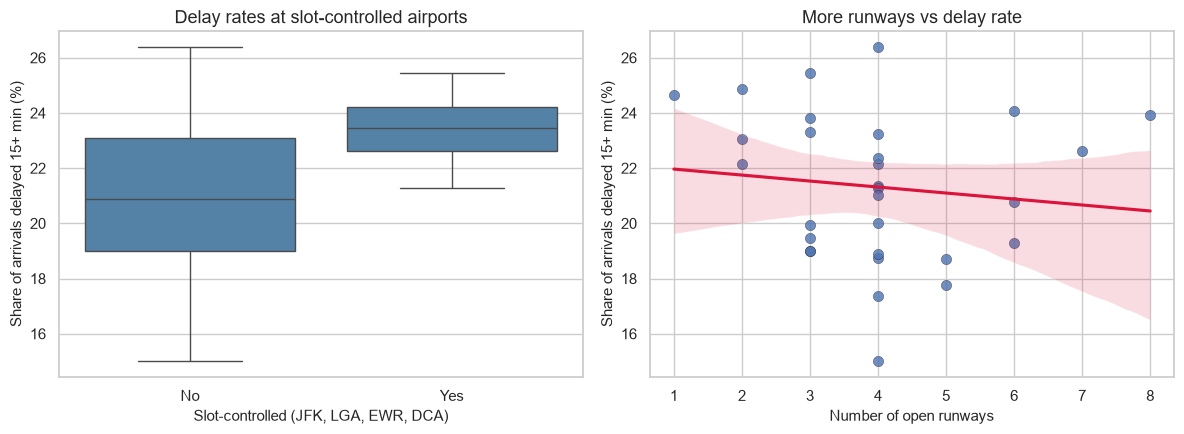

,airport,hub_size,slot_controlled,runway_count,enplanements_cy23,pct_delayed
27,SFO,Large,False,4,24191159,26.3819
6,DCA,Large,True,3,12365030,25.4619
11,FLL,Large,False,2,17063063,24.8731
25,SAN,Large,False,1,12190183,24.6592
3,BOS,Large,False,6,19962678,24.0680
22,ORD,Large,False,8,35843104,23.9105
10,EWR,Large,True,3,24575320,23.8219
29,TPA,Large,False,3,11677632,23.3036
18,MCO,Large,False,4,28033205,23.2351
17,LGA,Large,True,2,16173073,23.0585


In [27]:
# Ops profile vs delay rate (airport aggregate)
hub_pts = (
    clean.dropna(subset=["hub_size", "runway_count"])
    .groupby(
        ["airport", "hub_size", "slot_controlled", "runway_count", "enplanements_cy23"],
        as_index=False,
    )
    .agg(arr_flights=("arr_flights", "sum"), arr_del15=("arr_del15", "sum"))
)
hub_pts["pct_delayed"] = 100 * hub_pts["arr_del15"] / hub_pts["arr_flights"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(
    data=hub_pts,
    x="slot_controlled",
    y="pct_delayed",
    ax=axes[0],
    color="steelblue",
    order=[False, True],
)
axes[0].set_title("Delay rates at slot-controlled airports")
axes[0].set_xlabel("Slot-controlled (JFK, LGA, EWR, DCA)")
axes[0].set_ylabel("Share of arrivals delayed 15+ min (%)")
axes[0].set_xticks([0, 1], ["No", "Yes"])

sns.regplot(
    data=hub_pts,
    x="runway_count",
    y="pct_delayed",
    ax=axes[1],
    scatter_kws={"s": 55, "edgecolor": "k", "linewidths": 0.3},
    line_kws={"color": "crimson"},
)
axes[1].set_title("More runways vs delay rate")
axes[1].set_xlabel("Number of open runways")
axes[1].set_ylabel("Share of arrivals delayed 15+ min (%)")

fig.tight_layout()
fig.savefig(FIG_DIR / "10_hub_ops_vs_delay.png", dpi=150, bbox_inches="tight")
plt.show()

display(
    hub_pts.sort_values("pct_delayed", ascending=False)[
        ["airport", "hub_size", "slot_controlled", "runway_count", "enplanements_cy23", "pct_delayed"]
    ]
)


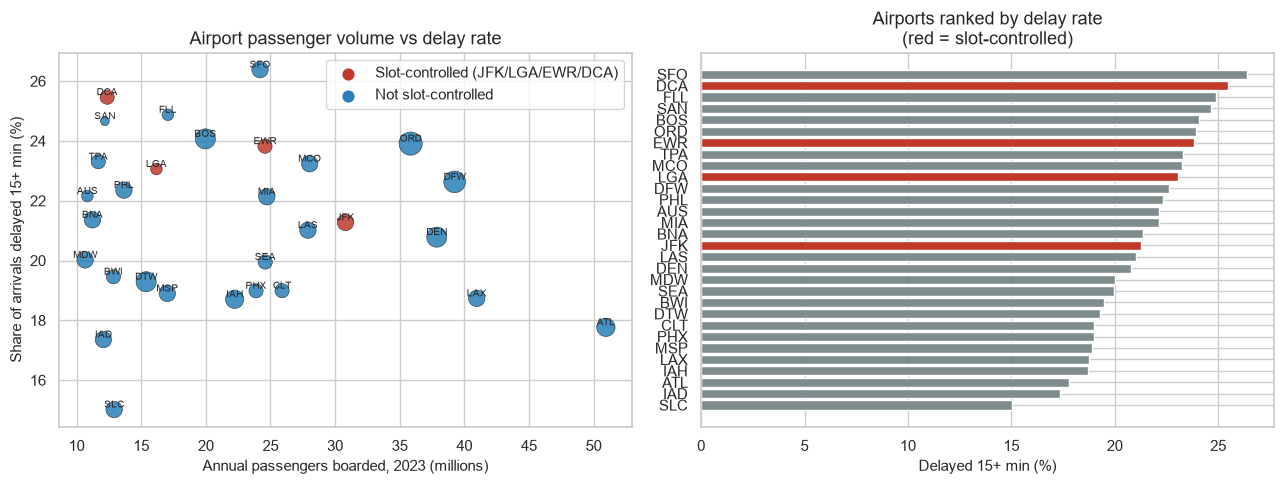

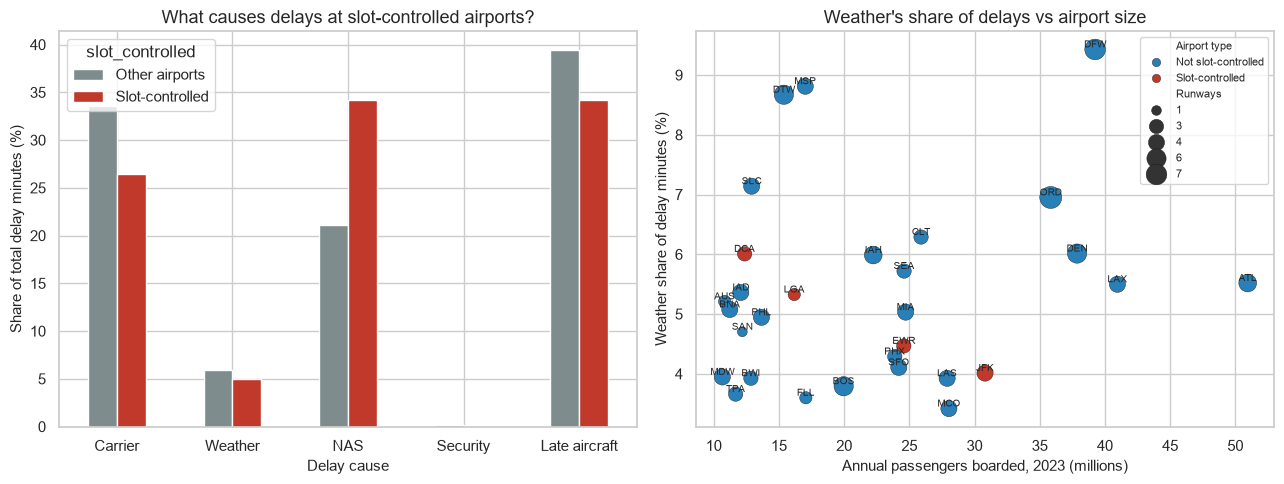

,Carrier,Weather,NAS,Security,Late aircraft
slot_controlled,,,,,
Other airports,33.5000,5.9000,21.1000,0.1000,39.4000
Slot-controlled,26.4000,5.0000,34.2000,0.1000,34.2000


In [28]:
# More hub/ops visuals: size, slot status, cause mix
hub_pts = (
    clean.dropna(subset=["hub_size", "runway_count", "enplanements_cy23"])
    .groupby(
        ["airport", "hub_size", "slot_controlled", "runway_count", "enplanements_cy23"],
        as_index=False,
    )
    .agg(
        arr_flights=("arr_flights", "sum"),
        arr_del15=("arr_del15", "sum"),
        arr_delay=("arr_delay", "sum"),
        **{c: (c, "sum") for c in CAUSE_DELAY_COLS},
    )
)
hub_pts["pct_delayed"] = 100 * hub_pts["arr_del15"] / hub_pts["arr_flights"]
hub_pts["enplanements_m"] = hub_pts["enplanements_cy23"] / 1e6
for c in CAUSE_DELAY_COLS:
    hub_pts[f"{c}_share"] = 100 * hub_pts[c] / hub_pts["arr_delay"].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = hub_pts["slot_controlled"].map({True: "#c0392b", False: "#2980b9"})
axes[0].scatter(
    hub_pts["enplanements_m"],
    hub_pts["pct_delayed"],
    s=np.clip(hub_pts["runway_count"] * 35, 40, 280),
    c=colors,
    edgecolor="k",
    linewidth=0.4,
    alpha=0.85,
)
for _, r in hub_pts.iterrows():
    axes[0].annotate(r["airport"], (r["enplanements_m"], r["pct_delayed"]), fontsize=7, ha="center", va="bottom")
axes[0].set_xlabel("Annual passengers boarded, 2023 (millions)")
axes[0].set_ylabel("Share of arrivals delayed 15+ min (%)")
axes[0].set_title("Airport passenger volume vs delay rate")
axes[0].scatter([], [], c="#c0392b", label="Slot-controlled (JFK/LGA/EWR/DCA)", s=60)
axes[0].scatter([], [], c="#2980b9", label="Not slot-controlled", s=60)
axes[0].legend(loc="best")

rank = hub_pts.sort_values("pct_delayed", ascending=True)
bar_colors = ["#c0392b" if s else "#7f8c8d" for s in rank["slot_controlled"]]
axes[1].barh(rank["airport"], rank["pct_delayed"], color=bar_colors)
axes[1].set_xlabel("Delayed 15+ min (%)")
axes[1].set_title("Airports ranked by delay rate\n(red = slot-controlled)")
fig.tight_layout()
fig.savefig(FIG_DIR / "11_enplanements_slot_delay.png", dpi=150, bbox_inches="tight")
plt.show()

cause_shares = (
    clean.groupby("slot_controlled")[CAUSE_DELAY_COLS].sum()
)
cause_shares = cause_shares.div(cause_shares.sum(axis=1), axis=0) * 100
cause_shares.index = cause_shares.index.map({True: "Slot-controlled", False: "Other airports"})
cause_shares = cause_shares.rename(
    columns={
        "carrier_delay": "Carrier",
        "weather_delay": "Weather",
        "nas_delay": "NAS",
        "security_delay": "Security",
        "late_aircraft_delay": "Late aircraft",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cause_shares.T.plot(kind="bar", ax=axes[0], color=["#7f8c8d", "#c0392b"], rot=0)
axes[0].set_ylabel("Share of total delay minutes (%)")
axes[0].set_title("What causes delays at slot-controlled airports?")
axes[0].set_xlabel("Delay cause")

sns.scatterplot(
    data=hub_pts,
    x="enplanements_m",
    y="weather_delay_share",
    hue="slot_controlled",
    hue_order=[False, True],
    size="runway_count",
    sizes=(50, 250),
    palette={True: "#c0392b", False: "#2980b9"},
    ax=axes[1],
    edgecolor="k",
    linewidth=0.3,
)
for _, r in hub_pts.iterrows():
    axes[1].annotate(r["airport"], (r["enplanements_m"], r["weather_delay_share"]), fontsize=7, ha="center", va="bottom")
axes[1].set_xlabel("Annual passengers boarded, 2023 (millions)")
axes[1].set_ylabel("Weather share of delay minutes (%)")
axes[1].set_title("Weather's share of delays vs airport size")
leg = axes[1].legend(loc="best", fontsize=8, title="")
# Rename legend entries for readability
for t in leg.get_texts():
    lab = t.get_text()
    if lab == "False":
        t.set_text("Not slot-controlled")
    elif lab == "True":
        t.set_text("Slot-controlled")
    elif lab == "slot_controlled":
        t.set_text("Airport type")
    elif lab == "runway_count":
        t.set_text("Runways")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_hub_cause_mix_and_weather.png", dpi=150, bbox_inches="tight")
plt.show()

display(cause_shares.round(1))


## 5. Summary statistics

Center (mean/median), spread (std / IQR via p25–p75), and shape (skew / excess kurtosis) for the main numeric fields.


In [29]:
stat_cols = [
    "arr_flights", "arr_del15", "arr_cancelled", "arr_diverted",
    "arr_delay", "pct_delayed", "pct_cancelled", "avg_delay_min_per_delayed",
    *CAUSE_DELAY_COLS,
]
stats_tbl = summarize_numeric(clean, cols=stat_cols)
print("Numeric summary statistics")
display(stats_tbl)

# Carrier-level delay rate (weighted by arrivals)
carrier_summary = (
    clean.groupby(["carrier", "carrier_name"], as_index=False)
    .agg(arr_flights=("arr_flights", "sum"),
         arr_del15=("arr_del15", "sum"),
         arr_cancelled=("arr_cancelled", "sum"),
         arr_delay=("arr_delay", "sum"))
)
carrier_summary["pct_delayed"] = 100 * carrier_summary["arr_del15"] / carrier_summary["arr_flights"]
carrier_summary["pct_cancelled"] = 100 * carrier_summary["arr_cancelled"] / carrier_summary["arr_flights"]
carrier_summary = carrier_summary.sort_values("pct_delayed", ascending=False)
print("\nCarrier delay rates (arrival-weighted)")
display(carrier_summary.head(10))


Numeric summary statistics


,n,mean,median,std,min,p25,p75,max,skew,kurtosis
column,,,,,,,,,,
arr_flights,8963,"1,138.3241",426.0000,"1,990.6793",1.0000,109.0000,"1,183.5000","21,854.0000",4.2810,27.5468
arr_del15,8962,241.4297,96.0000,412.9242,0.0000,24.0000,275.0000,"5,544.0000",4.1931,26.4583
arr_cancelled,8963,19.1807,4.0000,54.7601,0.0000,0.0000,15.0000,"1,508.0000",9.7456,167.4017
arr_diverted,8963,3.0861,1.0000,9.1170,0.0000,0.0000,2.0000,232.0000,9.1778,133.4202
arr_delay,8963,"18,449.6955","6,312.0000","35,413.3141",0.0000,"1,488.0000","20,052.0000","648,300.0000",5.4410,47.9550
pct_delayed,8962,22.7900,21.7704,10.3024,0.0000,16.1652,28.2248,100.0000,1.2518,6.4599
pct_cancelled,8963,1.7636,0.8086,2.9064,0.0000,0.0000,2.2690,100.0000,8.1616,190.4232
avg_delay_min_per_delayed,8770,69.4781,66.7213,25.6711,15.0000,54.0000,81.5285,654.6667,4.1422,63.8475
carrier_delay,8963,"6,003.4513","1,912.0000","12,361.9743",0.0000,444.0000,"6,246.0000","321,792.0000",6.5861,82.3678



Carrier delay rates (arrival-weighted)


,carrier,carrier_name,arr_flights,arr_del15,arr_cancelled,arr_delay,pct_delayed,pct_cancelled
6,F9,Frontier Airlines,"333,794.0000","92,887.0000","6,936.0000","7,664,002.0000",27.8276,2.0779
9,HA,Hawaiian Airlines Network,"13,003.0000","3,585.0000",62.0000,"190,695.0000",27.5706,0.4768
8,G7,GoJet Airlines LLC d/b/a United Express,"85,181.0000","21,562.0000","2,571.0000","2,188,980.0000",25.3132,3.0183
3,B6,JetBlue Airways,"349,156.0000","87,987.0000","7,065.0000","6,833,421.0000",25.1999,2.0235
7,G4,Allegiant Air,"39,451.0000","9,878.0000",337.0000,"952,210.0000",25.0387,0.8542
1,AA,American Airlines Network,"1,590,183.0000","376,725.0000","32,559.0000","32,949,597.0000",23.6907,2.0475
11,NK,Spirit Airlines,"307,963.0000","72,799.0000","8,074.0000","5,403,476.0000",23.6389,2.6217
12,OH,PSA Airlines Inc.,"276,761.0000","64,524.0000","11,293.0000","6,474,090.0000",23.3140,4.0804
20,ZW,Air Wisconsin Airlines Corp,"20,761.0000","4,805.0000",253.0000,"504,405.0000",23.1444,1.2186
2,AS,Alaska Airlines Network,"327,364.0000","73,375.0000","3,353.0000","3,816,102.0000",22.4139,1.0242


## 6. Visualization

Plots mirror the Lesson 4 style: distribution/shape, comparison across groups, time trend, and a correlation / composition view. Figures are also saved under `reports/figures/`.


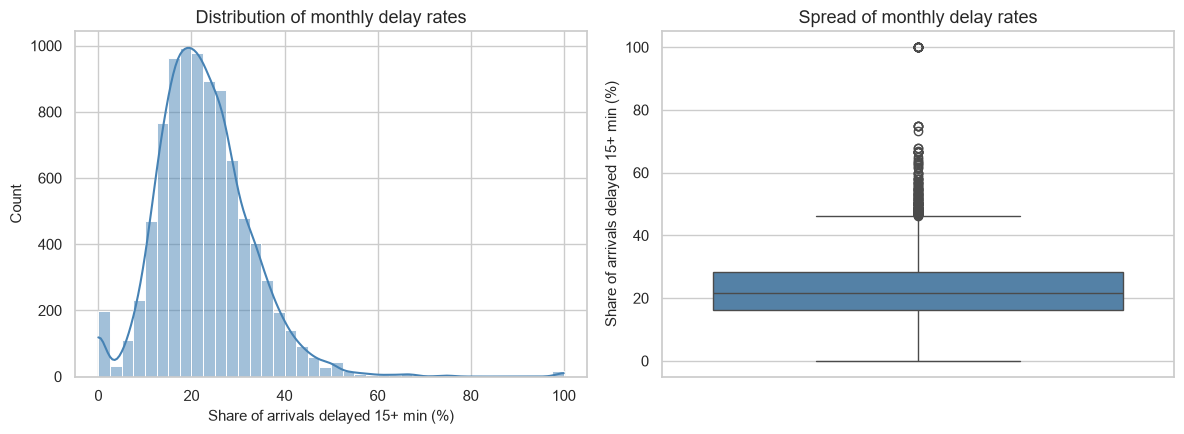

In [30]:
# 5.1 Distribution of airport-carrier monthly delay rates
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(clean["pct_delayed"].dropna(), bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of monthly delay rates")
axes[0].set_xlabel("Share of arrivals delayed 15+ min (%)")

sns.boxplot(y=clean["pct_delayed"].dropna(), ax=axes[1], color="steelblue")
axes[1].set_title("Spread of monthly delay rates")
axes[1].set_ylabel("Share of arrivals delayed 15+ min (%)")

fig.tight_layout()
fig.savefig(FIG_DIR / "01_delay_rate_distribution.png", dpi=150)
plt.show()


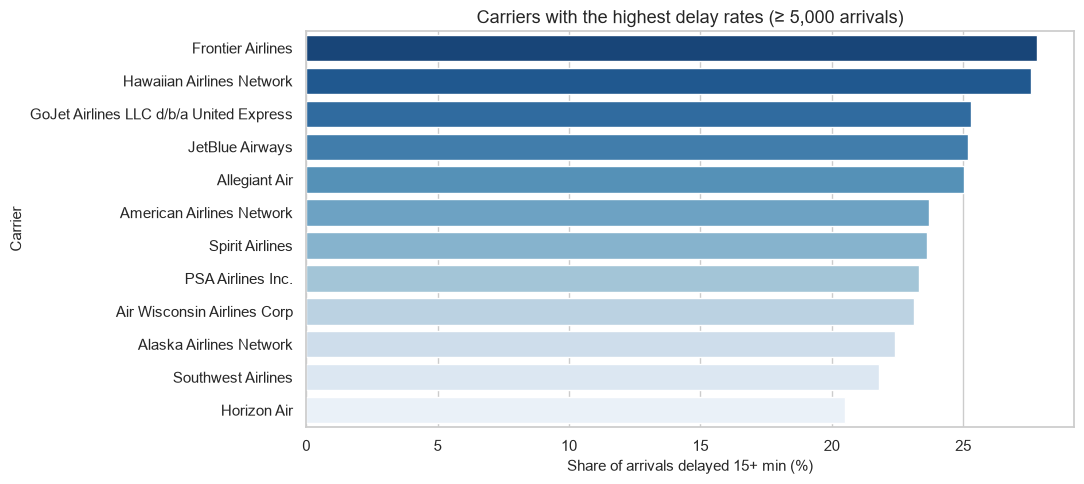

In [31]:
# 5.2 Top carriers by delay rate (min volume filter so tiny samples don't dominate)
min_flights = 5_000
plot_carriers = carrier_summary.query("arr_flights >= @min_flights").head(12)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=plot_carriers,
    y="carrier_name",
    x="pct_delayed",
    hue="carrier_name",
    legend=False,
    palette="Blues_r",
    ax=ax,
)
ax.set_title(f"Carriers with the highest delay rates (≥ {min_flights:,} arrivals)")
ax.set_xlabel("Share of arrivals delayed 15+ min (%)")
ax.set_ylabel("Carrier")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_carrier_delay_rates.png", dpi=150)
plt.show()


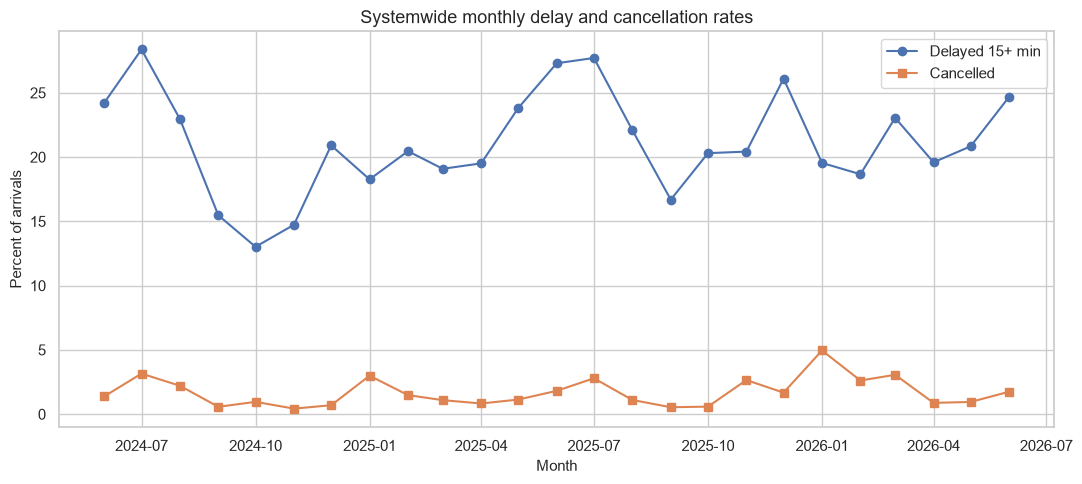

In [32]:
# 5.3 System-wide monthly trend
monthly = (
    clean.groupby("period", as_index=False)
    .agg(arr_flights=("arr_flights", "sum"),
         arr_del15=("arr_del15", "sum"),
         arr_cancelled=("arr_cancelled", "sum"))
)
monthly["pct_delayed"] = 100 * monthly["arr_del15"] / monthly["arr_flights"]
monthly["pct_cancelled"] = 100 * monthly["arr_cancelled"] / monthly["arr_flights"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["period"], monthly["pct_delayed"], marker="o", label="Delayed 15+ min")
ax.plot(monthly["period"], monthly["pct_cancelled"], marker="s", label="Cancelled")
ax.set_title("Systemwide monthly delay and cancellation rates")
ax.set_xlabel("Month")
ax.set_ylabel("Percent of arrivals")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03_monthly_delay_trend.png", dpi=150)
plt.show()


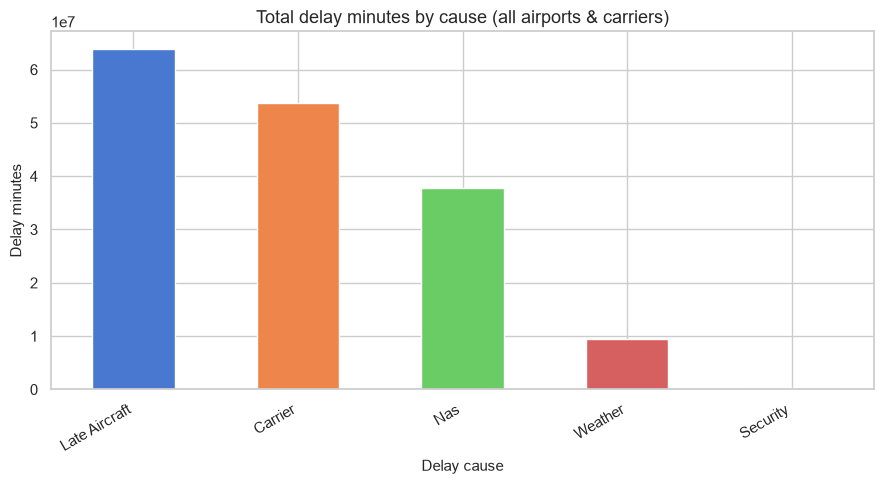

,share_pct
Late Aircraft,38.6715
Carrier,32.5409
Nas,22.9033
Weather,5.7566
Security,0.1277


In [33]:
# 5.4 Delay-cause composition (minutes)
cause_totals = clean[CAUSE_DELAY_COLS].sum().sort_values(ascending=False)
cause_totals.index = [
    c.replace("_delay", "").replace("_", " ").title()
    for c in cause_totals.index
]

fig, ax = plt.subplots(figsize=(9, 5))
cause_totals.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(cause_totals)))
ax.set_title("Total delay minutes by cause (all airports & carriers)")
ax.set_ylabel("Delay minutes")
ax.set_xlabel("Delay cause")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_delay_cause_minutes.png", dpi=150)
plt.show()

display((100 * cause_totals / cause_totals.sum()).rename("share_pct").to_frame())


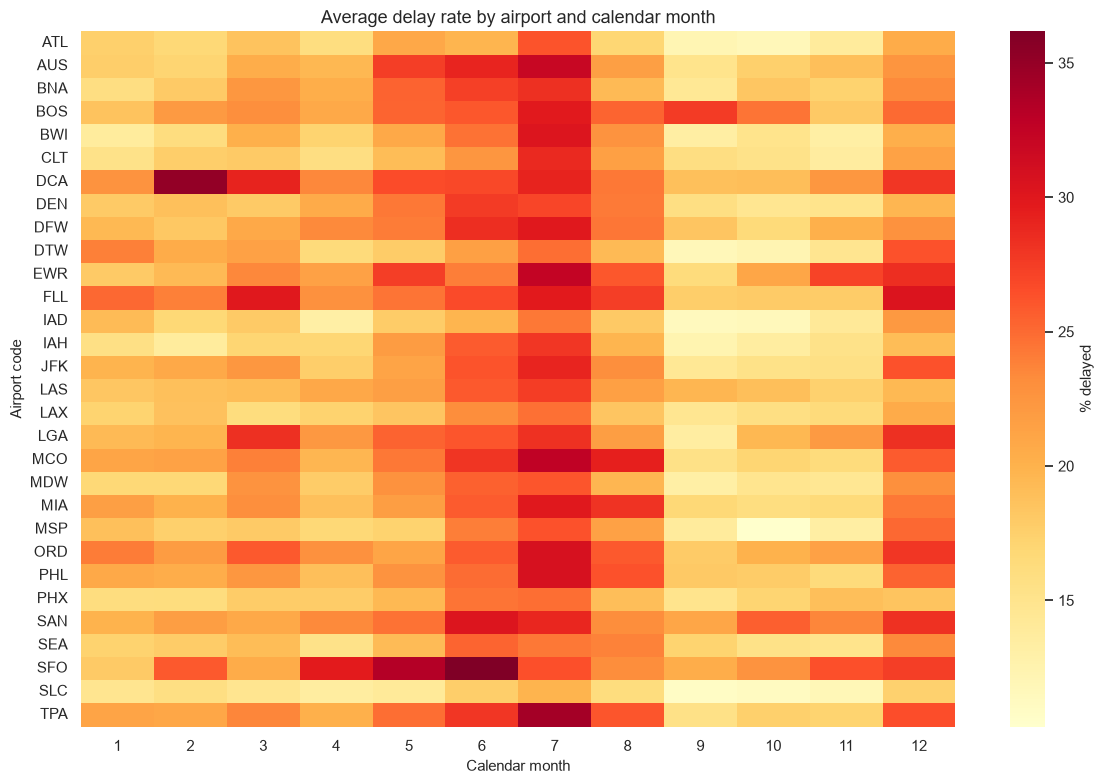

In [34]:
# 5.5 Airport heatmap: mean delay rate by airport × month-of-year
airport_month = (
    clean.groupby(["airport", "month"], as_index=False)
    .apply(
        lambda g: pd.Series({
            "pct_delayed": 100 * g["arr_del15"].sum() / g["arr_flights"].sum()
        }),
        include_groups=False,
    )
)
# pandas groupby.apply can return MultiIndex depending on version — normalize
if isinstance(airport_month.index, pd.MultiIndex):
    airport_month = airport_month.reset_index()

heat = airport_month.pivot(index="airport", columns="month", values="pct_delayed")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heat, cmap="YlOrRd", ax=ax, cbar_kws={"label": "% delayed"})
ax.set_title("Average delay rate by airport and calendar month")
ax.set_xlabel("Calendar month")
ax.set_ylabel("Airport code")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_airport_month_heatmap.png", dpi=150)
plt.show()


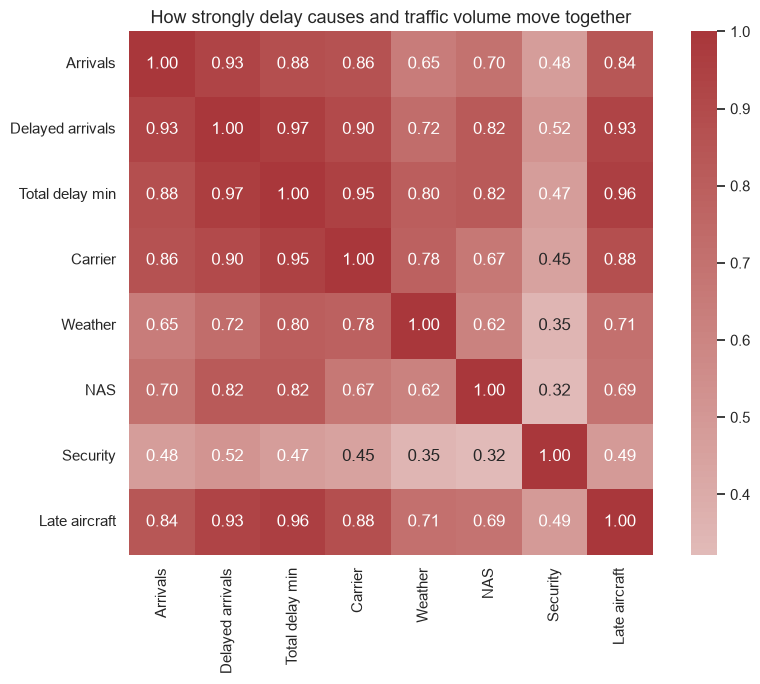

In [35]:
# 5.6 Correlation among delay-minute causes + volume
corr_cols = ["arr_flights", "arr_del15", "arr_delay", *CAUSE_DELAY_COLS]
corr = clean[corr_cols].corr()
corr = corr.rename(index={"arr_flights": "Arrivals", "arr_del15": "Delayed arrivals", "arr_delay": "Total delay min", "carrier_delay": "Carrier", "weather_delay": "Weather", "nas_delay": "NAS", "security_delay": "Security", "late_aircraft_delay": "Late aircraft"}, columns={"arr_flights": "Arrivals", "arr_del15": "Delayed arrivals", "arr_delay": "Total delay min", "carrier_delay": "Carrier", "weather_delay": "Weather", "nas_delay": "NAS", "security_delay": "Security", "late_aircraft_delay": "Late aircraft"})

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax, square=True)
ax.set_title("How strongly delay causes and traffic volume move together")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_delay_correlation.png", dpi=150)
plt.show()
